In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=75b7af5e38a21bccd1c7b92940b5492dfb625320b28d515253654d7deed978ee
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("/kaggle/input/datasets/kavl31/kdd-cup-1999-data/reduced_multiclass/reduced_multiclass/raw/full_5_classes.csv")

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection_type
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal


In [10]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

In [11]:
X_encoded = pd.get_dummies(X, columns=cat_cols)

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

Build SOM model

In [14]:
# SOM grid size (you can tune this)
som = MiniSom(
    x=10, y=10,            # grid size
    input_len=X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=1000)

Visualize SOM distance map (U-Matrix)

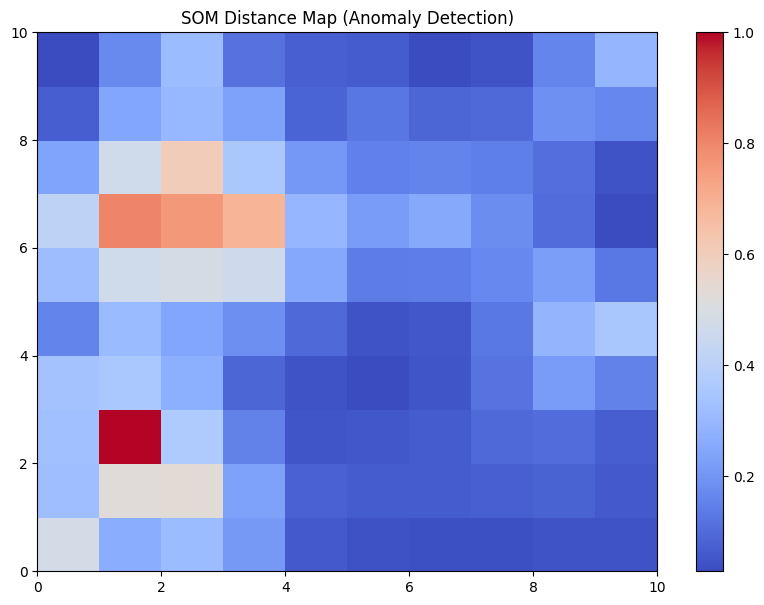

In [15]:
plt.figure(figsize=(10, 7))
plt.pcolor(som.distance_map().T, cmap='coolwarm')
plt.colorbar()
plt.title("SOM Distance Map (Anomaly Detection)")
plt.show()

Detect anomalies

In [16]:
threshold = 0.7  # tune this value

anomalies = []
normal = []

for i, x in enumerate(X_scaled):
    winner = som.winner(x)
    
    # distance from neuron weights
    dist = np.linalg.norm(x - som.get_weights()[winner])
    
    if dist > threshold:
        anomalies.append(i)
    else:
        normal.append(i)

print("Normal traffic:", len(normal))
print("Anomalies detected:", len(anomalies))

Normal traffic: 3554231
Anomalies detected: 1344200


Show suspicious traffic

In [17]:
anomalous_data = df.iloc[anomalies]
anomalous_data.head()

,duration,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,connection_type,protocol_type_icmp,protocol_type_tcp,protocol_type_udp
0,0,http,SF,215,45076,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0.0,0.0,normal,False,True,False
69,0,http,SF,212,1940,0,0,0,0,0,...,1.00,0.04,0.00,0.00,0.0,0.0,normal,False,True,False
1167,0,http,SF,284,43129,0,0,0,0,0,...,1.00,0.06,0.00,0.00,0.0,0.0,normal,False,True,False
1288,0,http,S2,182,9443,0,0,0,0,0,...,0.01,0.04,0.01,0.00,0.0,0.0,normal,False,True,False
1484,0,http,S1,201,68620,0,0,0,0,0,...,0.02,0.04,0.02,0.01,0.0,0.0,normal,False,True,False
